# Import Toolekit

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("darkgrid")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

import joblib

In [2]:
df = pd.read_csv("../assets/Regression-model-comparison/diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df= df.drop("Unnamed: 0", axis=1)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
df.shape

(53940, 10)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [8]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [16]:
categorical_cols = [col for col in df.columns if df[col].dtype == "str"]
numerical_cols = [col for col in df.columns if df[col].dtype in ["int64", "float64"]]

for col in categorical_cols:
    print(f"{col} : {df[col].unique()} \n") 


cut : <StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str 

color : <StringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str 

clarity : <StringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str 



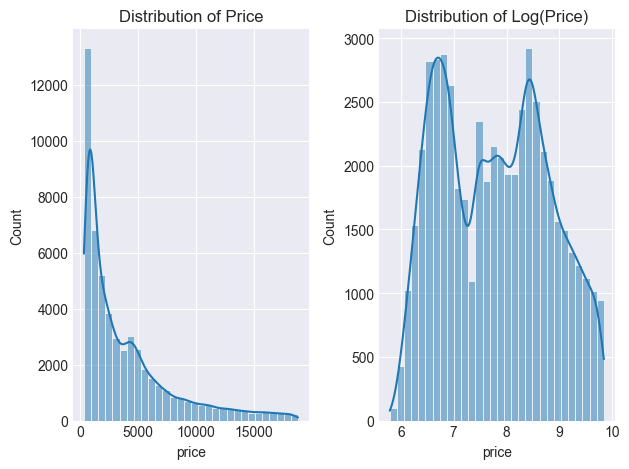

In [17]:
plt.subplot(1,2,1)
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of Price")

plt.subplot(1,2,2)
sns.histplot(np.log1p(df["price"]), bins=30, kde=True)
plt.title("Distribution of Log(Price)")
 
plt.tight_layout()
plt.show()

<Axes: >

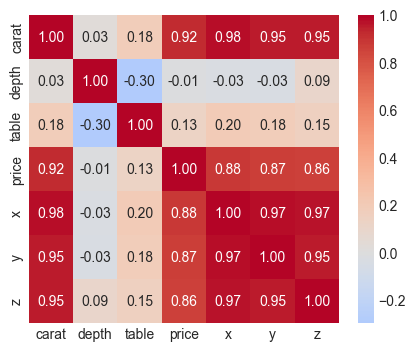

In [19]:
plt.figure(figsize=(5,4))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)

# Preprocessing

In [20]:
df[df[['x', 'y', 'z']]==0].count()

carat       0
cut         0
color       0
clarity     0
depth       0
table       0
price       0
x           8
y           7
z          20
dtype: int64

In [21]:
print (f" the dataset has {df.shape[0]} rows")
df = df[(df[['x', 'y', 'z']] != 0).all(axis=1) ]
print (f" the dataset has {df.shape[0]} rows")


 the dataset has 53940 rows
 the dataset has 53920 rows


In [23]:
numerical_cols
numerical_cols.remove("price")
numerical_cols

['carat', 'depth', 'table', 'x', 'y', 'z']

In [ ]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound, axis=0)

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53920.0,0.792346,0.456956,0.200,0.40,0.70,1.04,2.000
depth,53920.0,61.749229,1.269961,58.750,61.00,61.80,62.50,64.750
table,53920.0,57.438270,2.160902,51.500,56.00,57.00,59.00,63.500
price,53920.0,3930.993231,3987.280446,326.000,949.00,2401.00,5323.25,18823.000
x,53920.0,5.731463,1.118851,3.730,4.71,5.70,6.54,9.285
y,53920.0,5.733413,1.110978,3.680,4.72,5.71,6.54,9.270
z,53920.0,3.539362,0.691175,1.215,2.91,3.53,4.04,5.735


In [26]:
df.shape

(53920, 10)

In [27]:
df["volume"] = df["x"] * df["y"] * df["z"]
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,volume
0,0.23,Ideal,E,SI2,61.50,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,Premium,E,SI1,59.80,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,Good,E,VS1,58.75,63.5,327,4.05,4.07,2.31,38.076885
3,0.29,Premium,I,VS2,62.40,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,Good,J,SI2,63.30,58.0,335,4.34,4.35,2.75,51.917250


In [28]:
x = df.drop("price", axis=1)
y = df["price"]


In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
for col in categorical_cols:
    print(f"{col} : {df[col].unique()} \n") 

cut : <StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str 

color : <StringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str 

clarity : <StringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str 



In [31]:
cut_category = ['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
color_category = ['E', 'I', 'J', 'H', 'F', 'G', 'D']
clarity_category = ['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal", 
            OrdinalEncoder(
                categories=[cut_category, color_category, clarity_category],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),  
            categorical_cols
        ),
        ("scaler", StandardScaler(), numerical_cols)
    ]
)

# Training

In [40]:
models = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor( n_jobs=-1),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42,  n_jobs=-1),
    "Support Vector Regressor": SVR(),
    "XGBoost Regressor": XGBRegressor(random_state=42, n_jobs=-1) 
}

print("Model Initialization :")
for name in models:
    print(f"    - {name}")

Model Initialization :
    - Linear Regression
    - KNN Regressor
    - Decision Tree Regressor
    - Random Forest Regressor
    - Support Vector Regressor
    - XGBoost Regressor


In [42]:
cv_results = []
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring="r2", n_jobs=-1)

    cv_results.append({
        "Model": name,
        "CV R²": np.mean(scores),
        "CV R² Std": np.std(scores),
        "CV scores": scores
    })

    print(f"{name} : CV R² = {np.mean(scores):.4f} | CV R² Std =  {np.std(scores):.4f}")
    print("=" * 80)

Linear Regression : CV R² = 0.8838 | CV R² Std =  0.0017
KNN Regressor : CV R² = 0.9597 | CV R² Std =  0.0016
Decision Tree Regressor : CV R² = 0.9609 | CV R² Std =  0.0028
Random Forest Regressor : CV R² = 0.9790 | CV R² Std =  0.0010
Support Vector Regressor : CV R² = 0.4987 | CV R² Std =  0.0065
XGBoost Regressor : CV R² = 0.9797 | CV R² Std =  0.0008


In [43]:
cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV R²", ascending=False).reset_index(drop=True)

print("Cross-Validation Results summary: \n" + "=" * 80)
print(cv_results_df[["Model", "CV R²", "CV R² Std"]].to_string(index=False))

Cross-Validation Results summary: 
                   Model    CV R²  CV R² Std
       XGBoost Regressor 0.979655   0.000750
 Random Forest Regressor 0.978980   0.001041
 Decision Tree Regressor 0.960876   0.002805
           KNN Regressor 0.959666   0.001621
       Linear Regression 0.883848   0.001736
Support Vector Regressor 0.498684   0.006529


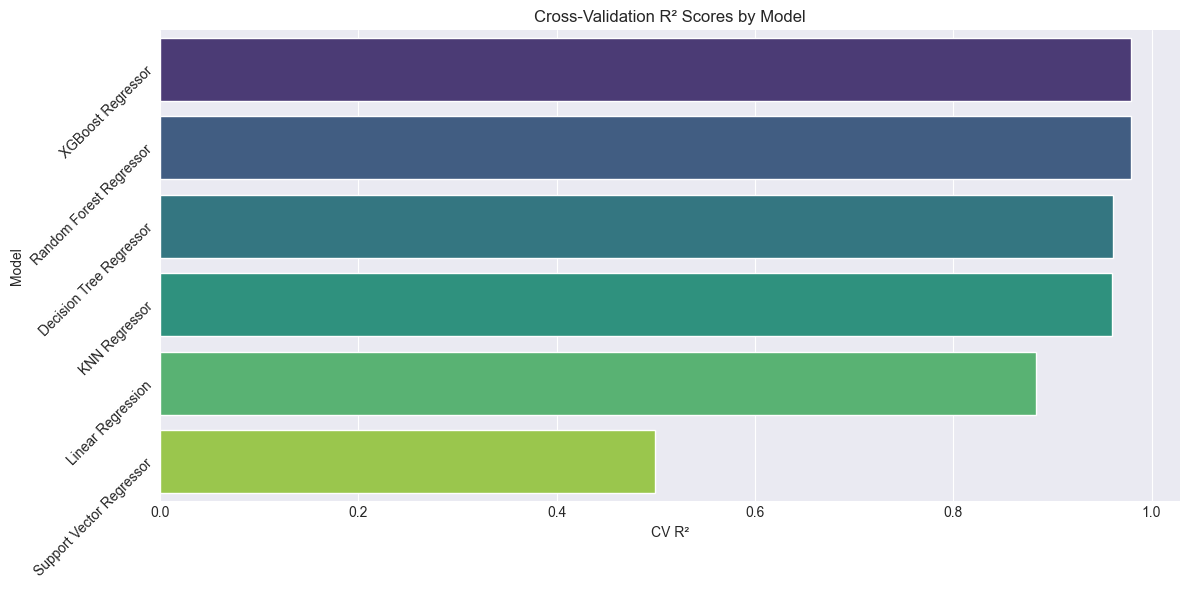

In [45]:
plt.figure(figsize=(12,6)) 

sns.barplot(x="CV R²", y="Model", data=cv_results_df, palette="viridis")
plt.title("Cross-Validation R² Scores by Model")
plt.xlabel("CV R²")
plt.ylabel("Model")
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

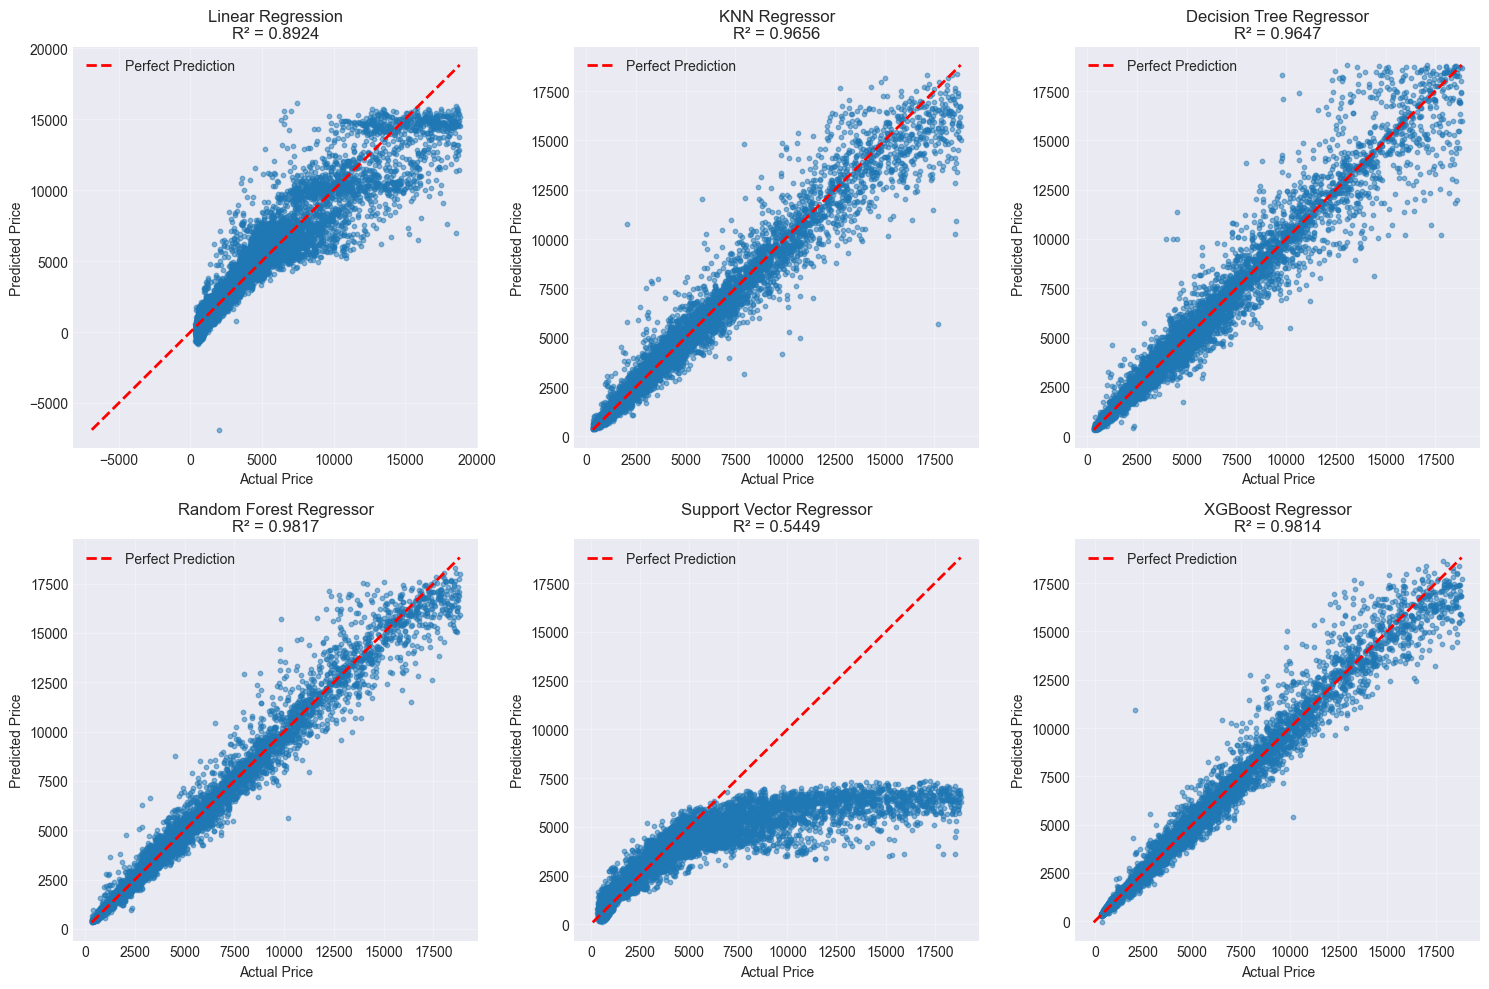

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    
    axes[idx].scatter(y_test, y_pred, alpha=0.5, s=10)
    
    # Draw perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    r2 = r2_score(y_test, y_pred)
    axes[idx].set_xlabel("Actual Price")
    axes[idx].set_ylabel("Predicted Price")
    axes[idx].set_title(f"{name}\nR² = {r2:.4f}")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
top_models = cv_results_df.head(3)["Model"].tolist()
print(f"Top 3 Models based on CV R² for hyperparameter tuning: {top_models}")


Top 3 Models based on CV R² for hyperparameter tuning: ['XGBoost Regressor', 'Random Forest Regressor', 'Decision Tree Regressor']


# Hyperparameter Tuning with GridSearchCV

In [54]:
param_grids = {
    "Linear Regression": {},

    "Decision Tree Regressor": {
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
       
    "Random Forest Regressor": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 20, 30],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },

    "XGBoost Regressor": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.8, 1.0]
    },

    "KNN Regressor": {
        "model__n_neighbors": [3, 5, 79],
        "model__weights": ['uniform', 'distance'],
        "model__p": [1, 2]
    },

    "Support Vector Regressor": {
        "model__C": [0.1, 1, 10],
        "model__gamma": ['scale', 'auto'],
        "model__kernel": ['rbf', 'linear']
    }
}

print("Hyperparameter Tuning with GridSearchCV :")

Hyperparameter Tuning with GridSearchCV :


In [55]:
best_estimators = {}
grid_results = []

for name in top_models:
    print(f"Tuning {name}...")
    model = models[name]
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    param_grid = param_grids.get(name, {})
    
    if not param_grid:
        print(f"No hyperparameters defined for {name}, skipping tuning.")
        continue
    
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="r2", n_jobs=-1)
    grid_search.fit(x_train, y_train)
    
    best_estimators[name] = grid_search.best_estimator_
    
    grid_results.append({
        "Model": name,
        "Best CV R²": grid_search.best_score_,
        "Best Params": grid_search.best_params_
    })
    
    print(f"Best CV R² for {name}: {grid_search.best_score_:.4f}")
    print(f"Best Hyperparameters for {name}: {grid_search.best_params_} \n")
    print("=" * 160 + "\n")

Tuning XGBoost Regressor...
Best CV R² for XGBoost Regressor: 0.9807
Best Hyperparameters for XGBoost Regressor: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 1.0} 


Tuning Random Forest Regressor...
Best CV R² for Random Forest Regressor: 0.9791
Best Hyperparameters for Random Forest Regressor: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200} 


Tuning Decision Tree Regressor...
Best CV R² for Decision Tree Regressor: 0.9681
Best Hyperparameters for Decision Tree Regressor: {'model__max_depth': 20, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10} 


